## Setup and Import Model ##

In [3]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if device.type == 'cuda':
  print(f'Running on GPU: {torch.cuda.get_device_name(0)}')
else:
  print('Running on CPU')

Running on GPU: NVIDIA GeForce RTX 2080 Super with Max-Q Design


### Importing Dataset ###

In [4]:
import pandas as pd

# path of each of the three csv files of the GoEmotions dataset
# Assuming the files are directly in MyDrive based on the file list
csv_path1 = '../data/goemotions_1.csv'
csv_path2 = '../data/goemotions_2.csv'
csv_path3 = '../data/goemotions_3.csv'

# List of the three files
csv_files = [csv_path1, csv_path2, csv_path3]

# generate DataFrame from each file then concatenate all three DataFrames into one
df = pd.concat((pd.read_csv(filename) for filename in csv_files), ignore_index=True)

#isolate the columns for emotion labels
label_cols = df.columns[9:].tolist()
#print(df.columns)
#print(label_cols)

# turn text column into lists
texts = df['text'].tolist()
# results in a list of lists representing the labels
labels = df[label_cols].values.tolist()

### Load BERT Tokenizer ###

In [5]:
from transformers import AutoTokenizer

MODEL_NAME = 'bert-base-uncased'

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(f'Tokenizer type loaded: {type(tokenizer).__name__}')


c:\Users\maewa\anaconda3\envs\bert_xai\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Tokenizer type loaded: BertTokenizer


### Define model ###

In [6]:
from transformers import AutoModelForSequenceClassification, AutoConfig

NUM_LABELS = 28

# configuration for multilabel classification
config = AutoConfig.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS
)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    config=config
)

# set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if device.type == 'cuda':
  print(f"Running on GPU: {torch.cuda.get_device_name(0)}")
else:
  print("Running on CPU (GPU not available or selected)")

# do this after loading state_dict
# model.to(device)

#print(f"Model Loaded: {MODEL_NAME} with {NUM_LABELS} output labels.")
#print(f"Running on device: {device}")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 369.44it/s, Materializing param=bert.pooler.dense.weight]                               
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those pa

Running on GPU: NVIDIA GeForce RTX 2080 Super with Max-Q Design


### Import pre-trained model weights ###

In [7]:
weights_path = "../weights/model_weights.pth"
state_dict = torch.load(weights_path, map_location=device)

model.load_state_dict(state_dict)

model.to(device)

model.eval()

C:\Users\maewa\AppData\Local\Temp\ipykernel_3100\689295023.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(weights_path, map_location=device)


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

## Data Pipeline ##

### Split data into train and test ###

In [8]:
from sklearn.model_selection import train_test_split

train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels, test_size=0.1, random_state=42
)

### Tokenize Train and Test sets ###

In [9]:
# Tokenize train text
train_encodings = tokenizer(
    train_texts,
    truncation=True,
    padding='max_length',
    max_length=128,
)

#Tokenize validation text
val_encodings = tokenizer(
    val_texts,
    truncation=True,
    padding='max_length',
    max_length=128,
)

print("Tokenization Example (First Text)")
print("Input text:", train_texts[0])
print("Input IDs (Partial):", train_encodings['input_ids'][0][:10], "...")
print("Attention Mask (partial):", train_encodings['attention_mask'][0][:10], '...')

Tokenization Example (First Text)
Input text: the longest week (2014) I don’t know if it’s still available but it was pretty good romantic comedy
Input IDs (Partial): [101, 1996, 6493, 2733, 1006, 2297, 1007, 1045, 2123, 1521] ...
Attention Mask (partial): [1, 1, 1, 1, 1, 1, 1, 1, 1, 1] ...


### Create Pytorch Dataset ###

In [10]:
class GoEmotionsDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __getitem__(self,idx):
        # converts the encodings lists to Pytorch tensors
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}

        # Add multi-hot encoded labels
        item['labels'] = self.labels[idx]
        return item

    def __len__(self):
        return len(self.labels)

### Instantiate datasets ###

In [11]:
train_dataset = GoEmotionsDataset(train_encodings, train_labels)
val_dataset = GoEmotionsDataset(val_encodings, val_labels)

### Set up Pytorch DataLoader ###

In [12]:
from torch.utils.data import DataLoader, RandomSampler, SequentialSampler

# Set batch size here
BATCH_SIZE = 64

# Training DataLoader
train_dataloader = DataLoader(
    train_dataset,
    # RandomSampler is used to shuffle data during each epoch
    sampler=RandomSampler(train_dataset),
    batch_size=BATCH_SIZE
)

# Validation DataLoader
val_dataloader = DataLoader(
    val_dataset,
    #SequentialSampler is used to ensure the data order is predictable
    sampler=SequentialSampler(val_dataset),
    batch_size=BATCH_SIZE
)

print(f'Train Dataloader created, batch size is {BATCH_SIZE}')
print(f'Validation Dataloader created with a batch size of {BATCH_SIZE}')

Train Dataloader created, batch size is 64
Validation Dataloader created with a batch size of 64


## SHAP Implementation ## 

In [13]:
import shap

# setup 
shap.initjs()
torch.cuda.empty_cache()

#### Get Text Labels ####

In [14]:
label_names = [
    "admiration", "amusement", "anger", "annoyance", "approval", "caring",
    "confusion", "curiosity", "desire", "disappointment", "disapproval",
    "disgust", "embarrassment", "excitement", "fear", "gratitude", "grief",
    "joy", "love", "nervousness", "optimism", "pride", "realization",
    "relief", "remorse", "sadness", "surprise", "neutral"
]
id2label = {i: name for i, name in enumerate(label_names)}

### Get text from DataLoader ###

In [15]:
# get text from dataloader
data_iter = iter(val_dataloader)
batch = next(data_iter)
input_ids = batch['input_ids']
texts = tokenizer.batch_decode(input_ids, skip_special_tokens=True)

### Wrapper Function ### 

In [16]:
import numpy as np
import scipy.special

def predict_wrapper(texts):
  # wrapper function translates text into token IDs and attention masks
  # tokenize the input text
  inputs = tokenizer(
      texts.tolist() if isinstance(texts, np.ndarray) else texts,
      return_tensors="pt",
      padding=True,
      truncation=True,
      max_length=128,
  ).to(device)

  with torch.no_grad():
    outputs=model(**inputs)

  # uses Sigmoid to calculate probabilities from logits
  logits = outputs.logits.detach().cpu().numpy()
  scores = scipy.special.expit(logits)
  return scores

### Compute SHAP values ###

In [17]:
# compute SHAP values
explainer = shap.Explainer(predict_wrapper, tokenizer)
shap_values = explainer(texts[:18])

# finds models top predicted emotion for the first 15 samples
for i in range(15):
    print(f"analyzing text: {texts[i]}\n")

    probs = predict_wrapper([texts[i]])[0]
    top_label_idx = np.argmax(probs)
    top_label_name = id2label[top_label_idx]

    print(f"Top BERT Prediction {top_label_name} ({probs[top_label_idx]:.2%})")

    # plot
    shap.plots.text(shap_values[i, :, top_label_idx])

PartitionExplainer explainer: 19it [01:11,  3.96s/it]                        

analyzing text: literally everywhere. there ' s nothing especially texan about any of this. i heard all of this in freaking sconsin.

Top BERT Prediction annoyance (22.75%)


analyzing text: [ name ] and [ name ] may be stronger, but [ name ] just gone mad. she ' s lost the plot for sure.

Top BERT Prediction disappointment (25.71%)


analyzing text: ik i ’ m crying rn

Top BERT Prediction sadness (85.84%)


analyzing text: he was cut yesterday, unfortunately

Top BERT Prediction sadness (60.51%)


analyzing text: nice, i saw them during the demo and was pretty impressed

Top BERT Prediction admiration (65.71%)


analyzing text: funny you ask

Top BERT Prediction amusement (61.09%)


analyzing text: minus the eyebrows i personally think it ’ s an attractive look. but the fucking eyebrows ruin it all.

Top BERT Prediction disgust (27.11%)


analyzing text: [ name ] is 16 and [ name ] is 19... but she ' s looks 16 as [ name ] 0. 0

Top BERT Prediction neutral (32.79%)


analyzing text: j e s u s c h r i s t those eyes

Top BERT Prediction neutral (17.75%)


analyzing text: my heart...

Top BERT Prediction neutral (12.08%)


analyzing text: okay, gotcha. does your wife have a lot of stress and anxiety from her job, or just in general?

Top BERT Prediction nervousness (34.79%)


analyzing text: finally a whole season and 3 jornadas too late.

Top BERT Prediction disappointment (21.18%)


analyzing text: * pounces on you * uwu you ’ re so warm

Top BERT Prediction love (44.81%)


analyzing text: higher ranking officer? also, i ' m curious, do mp have authority in scenarios like this?

Top BERT Prediction curiosity (79.45%)


analyzing text: wow, kinda lame that if this true, most of us probably don ' t know about it.

Top BERT Prediction surprise (60.56%)


## Bar Plots ##

PartitionExplainer explainer: 21it [01:15,  3.96s/it]                        


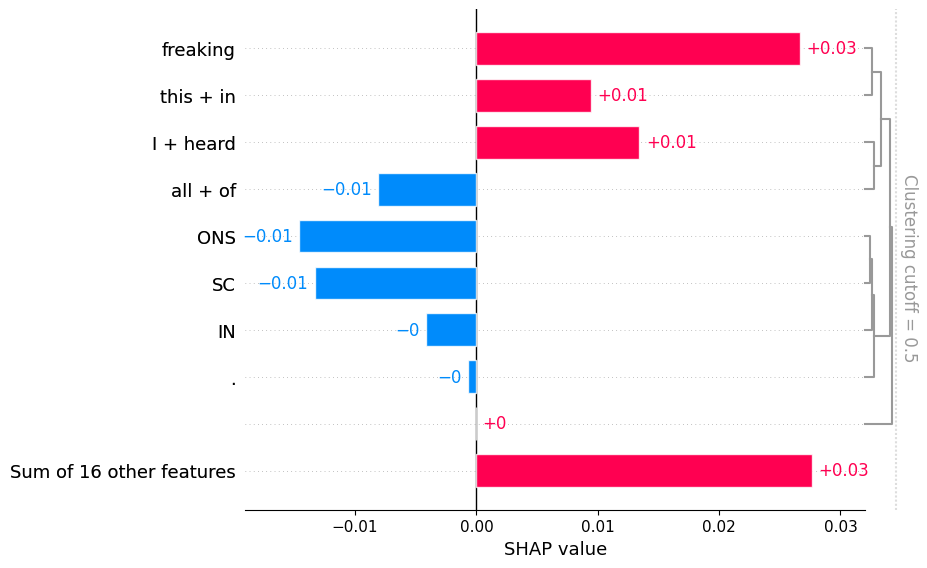

In [18]:
explainer = shap.Explainer(predict_wrapper, tokenizer)

sample_texts = val_texts[:20]

shap_values = explainer(sample_texts)

shap.plots.bar(shap_values[0, :, top_label_idx])



## Group labels with Ekman groups ##

In [19]:
# dictionary of the ekman mapping of the labels and neutral
ekman_mapping = {
    "anger": ["anger", "annoyance", "disapproval"],
    "disgust": ["disgust"],
    "fear": ["fear", "nervousness"],
    "joy": ["joy", "amusement", "approval", "excitement", "gratitude", "love", "optimism", "pride", "relief", "pride"],
    "sadness": ["sadness", "disappointment", "embarrassment", "grief", "remorse"],
    "surprise": ["surprise", "realization", "confusion", "curiosity"],
    "neutral": ["neutral"]
}

ekman_groups = ["anger", "disgust", "fear", "joy", "sadness", "surprise"] # choose to include "neutral" or not

### Collapse 28 label matrix to the 6 Ekman groups + neutral ###

In [20]:
all_labels_matrix = torch.stack([val_dataset[i]['labels'] for i in range(len(val_dataset))]).cpu().numpy()

ekman_matrix = np.zeros((all_labels_matrix.shape[0], len(ekman_groups)))

for i, group in enumerate(ekman_groups):
    target_indices = [k for k, v in id2label.items() if v in ekman_mapping[group]]

    if target_indices: 
        ekman_matrix[:, i] = all_labels_matrix[:, target_indices].max(axis=1)

print(f"Ekman matrix with shape: {ekman_matrix.shape}")

Ekman matrix with shape: (21123, 6)


## Run Iterative Stratifier ##

In [21]:
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

total_samples = len(val_texts)
train_n = 1000
test_n = total_samples - train_n

msss = MultilabelStratifiedShuffleSplit(n_splits=1, train_size=train_n, test_size=test_n, random_state=42)

for xai_indices, _ in msss.split(val_texts, ekman_matrix):
    sampled_indices = xai_indices

xai_sample_texts = [val_texts[i] for i in sampled_indices]
print(f"Successfully took {len(xai_sample_texts)} samples")

Successfully took 1000 samples


### Ekman Predict Wrapper ###

In [22]:
def predict_wrapper_ekman(texts):
    inputs = tokenizer(texts.tolist(), padding=True, truncation=True, max_length=128, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    # get sigmoid probabilities 
    probs_28 = torch.sigmoid(outputs.logits).cpu().numpy()

    # map these to the Ekman groups
    ekman_probs = []
    for group in ekman_groups:
        # getting indices of samples with sub-emotion labels belonging to this Ekman group
        indices = [k for k, v in id2label.items() if v in ekman_mapping[group]]
        
        # find the max probability from the sub-emotions
        group_prob = probs_28[:, indices].max(axis=1)
        ekman_probs.append(group_prob)

    return np.stack(ekman_probs, axis=1)

## Initialize SHAP Explainer ## 

In [23]:
explainer = shap.Explainer(predict_wrapper_ekman, tokenizer)

## Loop through samples (iterative stratification) ##

In [24]:
shap_batch_size = 20 
all_shap_results = []
total_samples = len(xai_sample_texts)

print(f"Starting SHAP Explanation for {total_samples} samples in 6 Ekman groups.")

for i in range(0, total_samples, shap_batch_size):
    batch_texts = np.array(xai_sample_texts[i : i + shap_batch_size])

    try: 
        print(f"Batch {i//shap_batch_size + 1}/{(total_samples//shap_batch_size)}.")

        batch_shap_values = explainer(batch_texts)
        all_shap_results.append(batch_shap_values)
    except Exception as e:
        print(f"Error at index {i}: {e}")
        continue



Starting SHAP Explanation for 1000 samples in 6 Ekman groups.
Batch 1/50.


PartitionExplainer explainer: 21it [01:22,  4.84s/it]                        


Batch 2/50.


PartitionExplainer explainer: 21it [01:49,  6.07s/it]                        


Batch 3/50.


PartitionExplainer explainer: 21it [01:28,  4.64s/it]                        


Batch 4/50.


PartitionExplainer explainer: 21it [01:27,  5.47s/it]                        


Batch 5/50.


PartitionExplainer explainer: 21it [01:19,  5.71s/it]                        


Batch 6/50.


PartitionExplainer explainer: 21it [01:30,  5.35s/it]                        


Batch 7/50.


PartitionExplainer explainer: 21it [01:23,  4.93s/it]                        


Batch 8/50.


PartitionExplainer explainer: 21it [01:20,  4.73s/it]                        


Batch 9/50.


PartitionExplainer explainer: 21it [01:38,  5.20s/it]                        


Batch 10/50.


PartitionExplainer explainer: 21it [01:37,  5.15s/it]                        


Batch 11/50.


PartitionExplainer explainer: 21it [01:08,  3.81s/it]                        


Batch 12/50.


PartitionExplainer explainer: 21it [01:24,  4.69s/it]                        


Batch 13/50.


PartitionExplainer explainer: 21it [01:13,  4.09s/it]                        


Batch 14/50.


PartitionExplainer explainer: 21it [01:13,  4.62s/it]                        


Batch 15/50.


PartitionExplainer explainer: 21it [01:10,  4.12s/it]                        


Batch 16/50.


PartitionExplainer explainer: 21it [01:26,  4.82s/it]                        


Batch 17/50.


PartitionExplainer explainer: 21it [01:27,  4.59s/it]                        


Batch 18/50.


PartitionExplainer explainer: 21it [01:07,  4.25s/it]                        


Batch 19/50.


PartitionExplainer explainer: 21it [01:07,  3.98s/it]                        


Batch 20/50.


PartitionExplainer explainer: 21it [01:07,  3.53s/it]                        


Batch 21/50.


PartitionExplainer explainer: 21it [01:25,  4.52s/it]                        


Batch 22/50.


PartitionExplainer explainer: 21it [01:13,  4.31s/it]                        


Batch 23/50.


PartitionExplainer explainer: 21it [01:00,  3.55s/it]                        


Batch 24/50.


PartitionExplainer explainer: 21it [01:15,  4.18s/it]                        


Batch 25/50.


PartitionExplainer explainer: 21it [01:00,  3.56s/it]                        


Batch 26/50.


PartitionExplainer explainer: 21it [01:13,  4.10s/it]                        


Batch 27/50.


PartitionExplainer explainer: 21it [01:09,  4.31s/it]                        


Batch 28/50.


PartitionExplainer explainer: 21it [01:05,  3.64s/it]                        


Batch 29/50.


PartitionExplainer explainer: 21it [01:07,  4.19s/it]                        


Batch 30/50.


PartitionExplainer explainer: 21it [01:04,  3.78s/it]                        


Batch 31/50.


PartitionExplainer explainer: 21it [01:05,  3.83s/it]                        


Batch 32/50.


PartitionExplainer explainer: 21it [01:16,  4.23s/it]                        


Batch 33/50.


PartitionExplainer explainer: 21it [01:11,  3.98s/it]                        


Batch 34/50.


PartitionExplainer explainer: 21it [00:56,  3.12s/it]                        


Batch 35/50.


PartitionExplainer explainer: 21it [01:21,  4.55s/it]                        


Batch 36/50.


PartitionExplainer explainer: 21it [01:18,  4.64s/it]                        


Batch 37/50.


PartitionExplainer explainer: 21it [01:00,  3.36s/it]                        


Batch 38/50.


PartitionExplainer explainer: 21it [01:09,  4.11s/it]                        


Batch 39/50.


PartitionExplainer explainer: 21it [01:46,  6.25s/it]                        


Batch 40/50.


PartitionExplainer explainer: 21it [01:22,  4.33s/it]                        


Batch 41/50.


PartitionExplainer explainer: 21it [01:19,  4.66s/it]                        


Batch 42/50.


PartitionExplainer explainer: 21it [01:07,  3.72s/it]                        


Batch 43/50.


PartitionExplainer explainer: 21it [01:36,  6.03s/it]                        


Batch 44/50.


PartitionExplainer explainer: 21it [01:16,  4.25s/it]                        


Batch 45/50.


PartitionExplainer explainer: 21it [01:25,  4.52s/it]                        


Batch 46/50.


PartitionExplainer explainer: 21it [01:16,  4.25s/it]                        


Batch 47/50.


PartitionExplainer explainer: 21it [01:28,  4.89s/it]                        


Batch 48/50.


PartitionExplainer explainer: 21it [01:20,  4.23s/it]                        


Batch 49/50.


PartitionExplainer explainer: 21it [01:49,  5.76s/it]                        


Batch 50/50.


PartitionExplainer explainer: 21it [01:39,  5.53s/it]                        


### Merge the results ###

In [25]:
all_values_list = []
all_base_values_list = []
all_data_list = []

for batch in all_shap_results:
    all_values_list.extend(list(batch.values))
    all_base_values_list.extend(list(batch.base_values))
    all_data_list.extend(list(batch.data))

global_shap_values = shap.Explanation(
    values=np.array(all_values_list, dtype=object),
    base_values=np.array(all_base_values_list),
    data=np.array(all_data_list, dtype=object),
    feature_names=ekman_groups  
)

print("SHAP Processing Complete")

SHAP Processing Complete


### Plot results ###

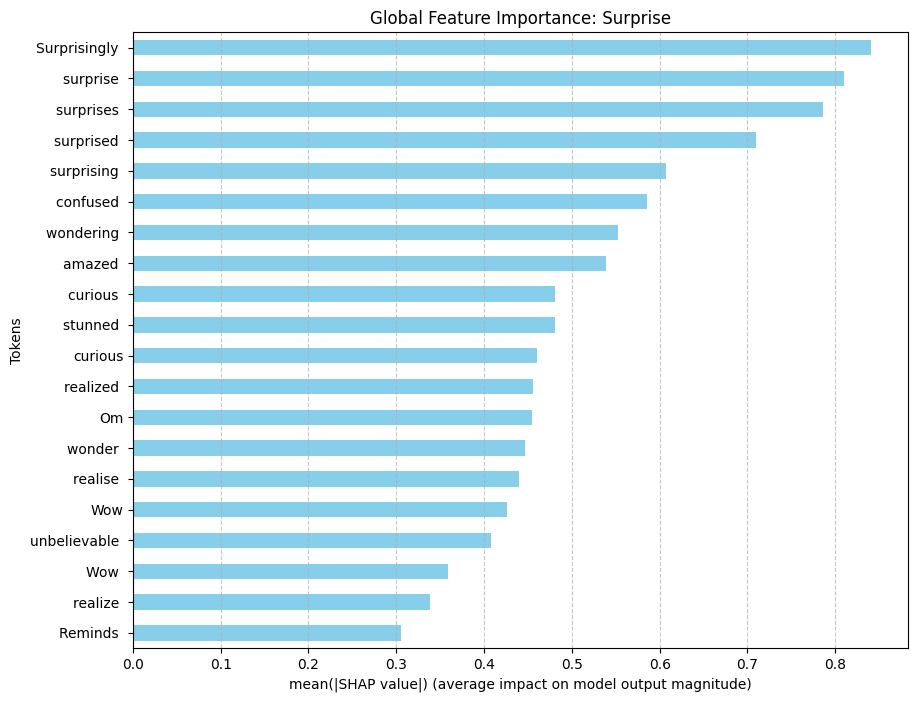

In [33]:
import matplotlib.pyplot as plt

target_idx = 5

all_words = []
all_impacts = []

for i in range(len(global_shap_values)):

    tokens = global_shap_values.data[i]

    values = global_shap_values.values[i][:, target_idx]
    
    all_words.extend(tokens)
    all_impacts.extend(values)

df_importance = pd.DataFrame({'word': all_words, 'impact': all_impacts})

global_scores = df_importance.groupby('word')['impact'].apply(lambda x: np.mean(np.abs(x))).sort_values(ascending=False)

special_tokens = ['[CLS]', '[SEP]', '', ' ', ' ', '[PAD]']
global_scores = global_scores[~global_scores.index.isin(special_tokens)]

top_n = 20
plt.figure(figsize=(10, 8))
global_scores.head(top_n).plot(kind='barh', color='skyblue').invert_yaxis()
plt.title(f"Global Feature Importance: {ekman_groups[target_idx].capitalize()}")
plt.xlabel("mean(|SHAP value|) (average impact on model output magnitude)")
plt.ylabel("Tokens")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## Take Stratified Sample ##

In [27]:
# get dataset from validation dataloader
val_dataset = val_dataloader.dataset

# extract labels 
all_labels_matrix = torch.stack([val_dataset[i]['labels'] for i in range(len(val_dataset))]).cpu().numpy()

sampled_indices = []
samples_per_class = 100

# loop through each of 28 emotion indices
for cls in range(all_labels_matrix.shape[1]):
    label_name = id2label[cls]

    # find indices where this label is active i.e. equal to 1
    cls_indices = np.where(all_labels_matrix[:, cls] == 1)[0]

    if len(cls_indices) == 0:
        print(f"No samples found for {label_name}")
        continue

    np.random.seed(42)
    np.random.shuffle(cls_indices)

    selected = cls_indices[:samples_per_class]
    sampled_indices.extend(selected)

    print(f"Sampled {len(selected)} instances for {label_name}")

dedup_indices = sorted(list(set(sampled_indices)))
print(f"Final Unique Sample Size: {len(dedup_indices)}")

xai_sample_texts = [val_texts[i] for i in dedup_indices]

Sampled 100 instances for admiration
Sampled 100 instances for amusement
Sampled 100 instances for anger
Sampled 100 instances for annoyance
Sampled 100 instances for approval
Sampled 100 instances for caring
Sampled 100 instances for confusion
Sampled 100 instances for curiosity
Sampled 100 instances for desire
Sampled 100 instances for disappointment
Sampled 100 instances for disapproval
Sampled 100 instances for disgust
Sampled 100 instances for embarrassment
Sampled 100 instances for excitement
Sampled 100 instances for fear
Sampled 100 instances for gratitude
Sampled 50 instances for grief
Sampled 100 instances for joy
Sampled 100 instances for love
Sampled 100 instances for nervousness
Sampled 100 instances for optimism
Sampled 100 instances for pride
Sampled 100 instances for realization
Sampled 100 instances for relief
Sampled 100 instances for remorse
Sampled 100 instances for sadness
Sampled 100 instances for surprise
Sampled 100 instances for neutral
Final Unique Sample Size

In [28]:
# WARNING this took me ~2 hours to run 
shap_batch = 20
all_shap_results = []
total_texts = len(xai_sample_texts)

print(f"Starting SHAP explanation {total_texts} unique samples.")

for i in range(0, total_texts, shap_batch):
    batch_texts = xai_sample_texts[i : i + shap_batch]

    #generate SHAP values
    try:
        print(f"Processing batch {i//shap_batch + 1} (Indices {i} to {min(i+shap_batch, total_texts)})")
        batch_shap_values = explainer(batch_texts)
        all_shap_results.append(batch_shap_values)
    except Exception as e:
        print(f"Error in batch starting at index {i}: {e}")
        continue

# merge shap values into one Explanation object
global_shap_values = all_shap_results[0]

print("Processing complete")

Starting SHAP explanation 2645 unique samples.
Processing batch 1 (Indices 0 to 20)


PartitionExplainer explainer: 21it [01:26,  4.81s/it]                        


Processing batch 2 (Indices 20 to 40)


PartitionExplainer explainer: 21it [01:46,  5.61s/it]                        


Processing batch 3 (Indices 40 to 60)


PartitionExplainer explainer: 21it [01:40,  5.58s/it]                        


Processing batch 4 (Indices 60 to 80)


PartitionExplainer explainer: 21it [01:48,  6.38s/it]                        


Processing batch 5 (Indices 80 to 100)


PartitionExplainer explainer: 21it [01:16,  4.27s/it]                        


Processing batch 6 (Indices 100 to 120)


PartitionExplainer explainer: 21it [01:30,  4.74s/it]                        


Processing batch 7 (Indices 120 to 140)


PartitionExplainer explainer: 21it [01:26,  4.57s/it]                        


Processing batch 8 (Indices 140 to 160)


PartitionExplainer explainer: 21it [01:19,  4.42s/it]                        


Processing batch 9 (Indices 160 to 180)


PartitionExplainer explainer: 21it [01:41,  5.33s/it]                        


Processing batch 10 (Indices 180 to 200)


PartitionExplainer explainer: 21it [01:43,  5.45s/it]                        


Processing batch 11 (Indices 200 to 220)


PartitionExplainer explainer: 21it [01:28,  4.89s/it]                        


Processing batch 12 (Indices 220 to 240)


PartitionExplainer explainer: 21it [01:21,  4.54s/it]                        


Processing batch 13 (Indices 240 to 260)


PartitionExplainer explainer: 21it [01:16,  4.05s/it]                        


Processing batch 14 (Indices 260 to 280)


PartitionExplainer explainer: 21it [01:37,  5.43s/it]                        


Processing batch 15 (Indices 280 to 300)


PartitionExplainer explainer: 21it [01:37,  5.43s/it]                        


Processing batch 16 (Indices 300 to 320)


PartitionExplainer explainer: 21it [01:44,  5.78s/it]                        


Processing batch 17 (Indices 320 to 340)


PartitionExplainer explainer: 21it [01:58,  6.22s/it]                        


Processing batch 18 (Indices 340 to 360)


PartitionExplainer explainer: 21it [01:24,  4.67s/it]                        


Processing batch 19 (Indices 360 to 380)


PartitionExplainer explainer: 21it [01:19,  4.41s/it]                        


Processing batch 20 (Indices 380 to 400)


PartitionExplainer explainer: 21it [01:13,  4.61s/it]                        


Processing batch 21 (Indices 400 to 420)


PartitionExplainer explainer: 21it [01:15,  4.17s/it]                        


Processing batch 22 (Indices 420 to 440)


PartitionExplainer explainer: 21it [01:28,  4.64s/it]                        


Processing batch 23 (Indices 440 to 460)


PartitionExplainer explainer: 21it [01:25,  4.49s/it]                        


Processing batch 24 (Indices 460 to 480)


PartitionExplainer explainer: 21it [01:25,  4.50s/it]                        


Processing batch 25 (Indices 480 to 500)


PartitionExplainer explainer: 21it [01:20,  5.06s/it]                        


Processing batch 26 (Indices 500 to 520)


PartitionExplainer explainer: 21it [01:08,  4.05s/it]                        


Processing batch 27 (Indices 520 to 540)


PartitionExplainer explainer: 21it [01:27,  4.58s/it]                        


Processing batch 28 (Indices 540 to 560)


PartitionExplainer explainer: 21it [02:00,  6.36s/it]                        


Processing batch 29 (Indices 560 to 580)


PartitionExplainer explainer: 21it [01:37,  5.42s/it]                        


Processing batch 30 (Indices 580 to 600)


PartitionExplainer explainer: 21it [01:45,  5.55s/it]                        


Processing batch 31 (Indices 600 to 620)


PartitionExplainer explainer: 21it [01:41,  5.35s/it]                        


Processing batch 32 (Indices 620 to 640)


PartitionExplainer explainer: 21it [01:43,  5.46s/it]                        


Processing batch 33 (Indices 640 to 660)


PartitionExplainer explainer: 21it [01:39,  5.52s/it]                        


Processing batch 34 (Indices 660 to 680)


PartitionExplainer explainer: 21it [01:44,  5.48s/it]                        


Processing batch 35 (Indices 680 to 700)


PartitionExplainer explainer: 21it [01:17,  4.58s/it]                        


Processing batch 36 (Indices 700 to 720)


PartitionExplainer explainer: 21it [01:52,  5.92s/it]                        


Processing batch 37 (Indices 720 to 740)


PartitionExplainer explainer: 21it [01:16,  4.26s/it]                        


Processing batch 38 (Indices 740 to 760)


PartitionExplainer explainer: 21it [01:23,  4.62s/it]                        


Processing batch 39 (Indices 760 to 780)


PartitionExplainer explainer: 21it [01:18,  4.35s/it]                        


Processing batch 40 (Indices 780 to 800)


PartitionExplainer explainer: 21it [01:37,  5.15s/it]                        


Processing batch 41 (Indices 800 to 820)


PartitionExplainer explainer: 21it [01:40,  5.31s/it]                        


Processing batch 42 (Indices 820 to 840)


PartitionExplainer explainer: 21it [01:20,  4.23s/it]                        


Processing batch 43 (Indices 840 to 860)


PartitionExplainer explainer: 21it [01:45,  5.53s/it]                        


Processing batch 44 (Indices 860 to 880)


PartitionExplainer explainer: 21it [01:21,  4.81s/it]                        


Processing batch 45 (Indices 880 to 900)


PartitionExplainer explainer: 21it [01:21,  4.77s/it]                        


Processing batch 46 (Indices 900 to 920)


PartitionExplainer explainer: 21it [01:24,  4.68s/it]                        


Processing batch 47 (Indices 920 to 940)


PartitionExplainer explainer: 21it [01:49,  5.77s/it]                        


Processing batch 48 (Indices 940 to 960)


PartitionExplainer explainer: 21it [01:53,  6.31s/it]                        


Processing batch 49 (Indices 960 to 980)


PartitionExplainer explainer: 21it [01:26,  4.53s/it]                        


Processing batch 50 (Indices 980 to 1000)


PartitionExplainer explainer: 21it [01:27,  4.87s/it]                        


Processing batch 51 (Indices 1000 to 1020)


PartitionExplainer explainer:  75%|███████▌  | 15/20 [00:56<00:23,  4.75s/it]


KeyboardInterrupt: 

In [ ]:
all_values_list = []
all_base_values_list = []
all_data_list = []

for batch in all_shap_results:
    all_values_list.extend(list(batch.values))
    all_base_values_list.extend(list(batch.base_values))
    all_data_list.extend(list(batch.data))


global_shap_values = shap.Explanation(
    values=np.array(all_values_list, dtype=object), 
    base_values=np.array(all_base_values_list),
    data=np.array(all_data_list, dtype=object),     
    feature_names=all_shap_results[0].feature_names
)

print(f"Successfully merged {len(global_shap_values)} samples manually.")

Successfully merged 2645 samples manually.


In [ ]:
for idx, name in id2label.items():
    print(f"Index {idx}: {name}")

Index 0: admiration
Index 1: amusement
Index 2: anger
Index 3: annoyance
Index 4: approval
Index 5: caring
Index 6: confusion
Index 7: curiosity
Index 8: desire
Index 9: disappointment
Index 10: disapproval
Index 11: disgust
Index 12: embarrassment
Index 13: excitement
Index 14: fear
Index 15: gratitude
Index 16: grief
Index 17: joy
Index 18: love
Index 19: nervousness
Index 20: optimism
Index 21: pride
Index 22: realization
Index 23: relief
Index 24: remorse
Index 25: sadness
Index 26: surprise
Index 27: neutral


In [ ]:
import matplotlib.pyplot as plt

target_idx = 15

all_words = []
all_impacts = []

for i in range(len(global_shap_values)):

    tokens = global_shap_values.data[i]

    values = global_shap_values.values[i][:, target_idx]
    
    all_words.extend(tokens)
    all_impacts.extend(values)

df_importance = pd.DataFrame({'word': all_words, 'impact': all_impacts})

global_scores = df_importance.groupby('word')['impact'].apply(lambda x: np.mean(np.abs(x))).sort_values(ascending=False)

special_tokens = ['[CLS]', '[SEP]', '', ' ', ' ', '[PAD]']
global_scores = global_scores[~global_scores.index.isin(special_tokens)]

top_n = 20
plt.figure(figsize=(10, 8))
global_scores.head(top_n).plot(kind='barh', color='skyblue').invert_yaxis()
plt.title(f"Global Feature Importance: {id2label[target_idx].capitalize()}")
plt.xlabel("mean(|SHAP value|) (average impact on model output magnitude)")
plt.ylabel("Tokens")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


NameError: name 'global_shap_values' is not defined